### Importación de datos



In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [84]:
tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
facturacion = [
    tienda['Precio'].sum(),
    tienda2['Precio'].sum(),
    tienda3['Precio'].sum(),
    tienda4['Precio'].sum()
]

print(facturacion)

[np.float64(1150880400.0), np.float64(1116343500.0), np.float64(1098019600.0), np.float64(1038375700.0)]


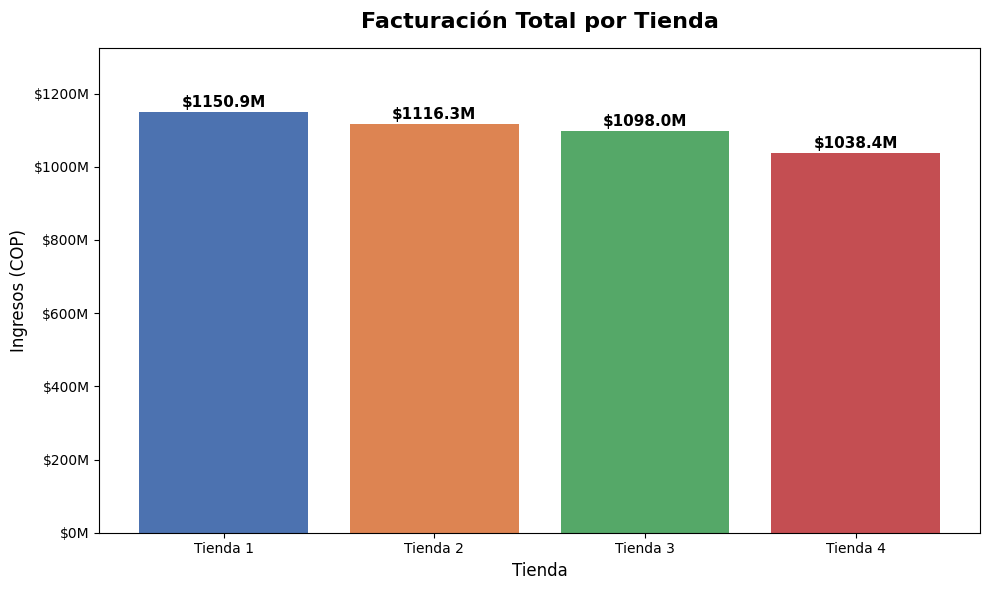

In [87]:
fig, grafica_facturacion = plt.subplots(figsize=(10, 6))
barras = grafica_facturacion.bar(tiendas, facturacion, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

for barra, valor in zip(barras, facturacion):
    grafica_facturacion.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 5_000_000,
        f'${valor/1_000_000:.1f}M',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

grafica_facturacion.set_title('Facturación Total por Tienda', fontsize=16, fontweight='bold', pad=15)
grafica_facturacion.set_xlabel('Tienda', fontsize=12)
grafica_facturacion.set_ylabel('Ingresos (COP)', fontsize=12)
grafica_facturacion.set_ylim(0, max(facturacion) * 1.15)
grafica_facturacion.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1_000_000:.0f}M'))

plt.tight_layout()
plt.show()

# 2. Ventas por categoría

In [71]:
tienda['Producto'].value_counts().head(5)

,count
Producto,
Microondas,60
TV LED UHD 4K,60
Armario,60
Secadora de ropa,58
Mesa de noche,56


In [6]:
tienda['Categoría del Producto'].unique()

array(['Electrónicos', 'Muebles', 'Juguetes', 'Electrodomésticos',
       'Artículos para el hogar', 'Deportes y diversión', 'Libros',
       'Instrumentos musicales'], dtype=object)

In [91]:
ventas_productos1 = tienda['Producto'].value_counts()
ventas_productos2 = tienda2['Producto'].value_counts()
ventas_productos3 = tienda3['Producto'].value_counts()
ventas_productos4 = tienda4['Producto'].value_counts()

comparacion_productos = pd.concat(
    [ventas_productos1, ventas_productos2, ventas_productos3, ventas_productos4],
    axis=1
)

comparacion_productos.columns = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
comparacion_productos = comparacion_productos.fillna(0)
comparacion_productos

,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Producto,,,,
Microondas,60,62,36,48
TV LED UHD 4K,60,45,42,40
Armario,60,54,49,34
Secadora de ropa,58,57,45,40
Mesa de noche,56,44,55,55
Bloques de construcción,56,54,35,54
Balón de baloncesto,55,42,50,50
Bicicleta,54,45,52,45
Vaso térmico,54,47,38,48


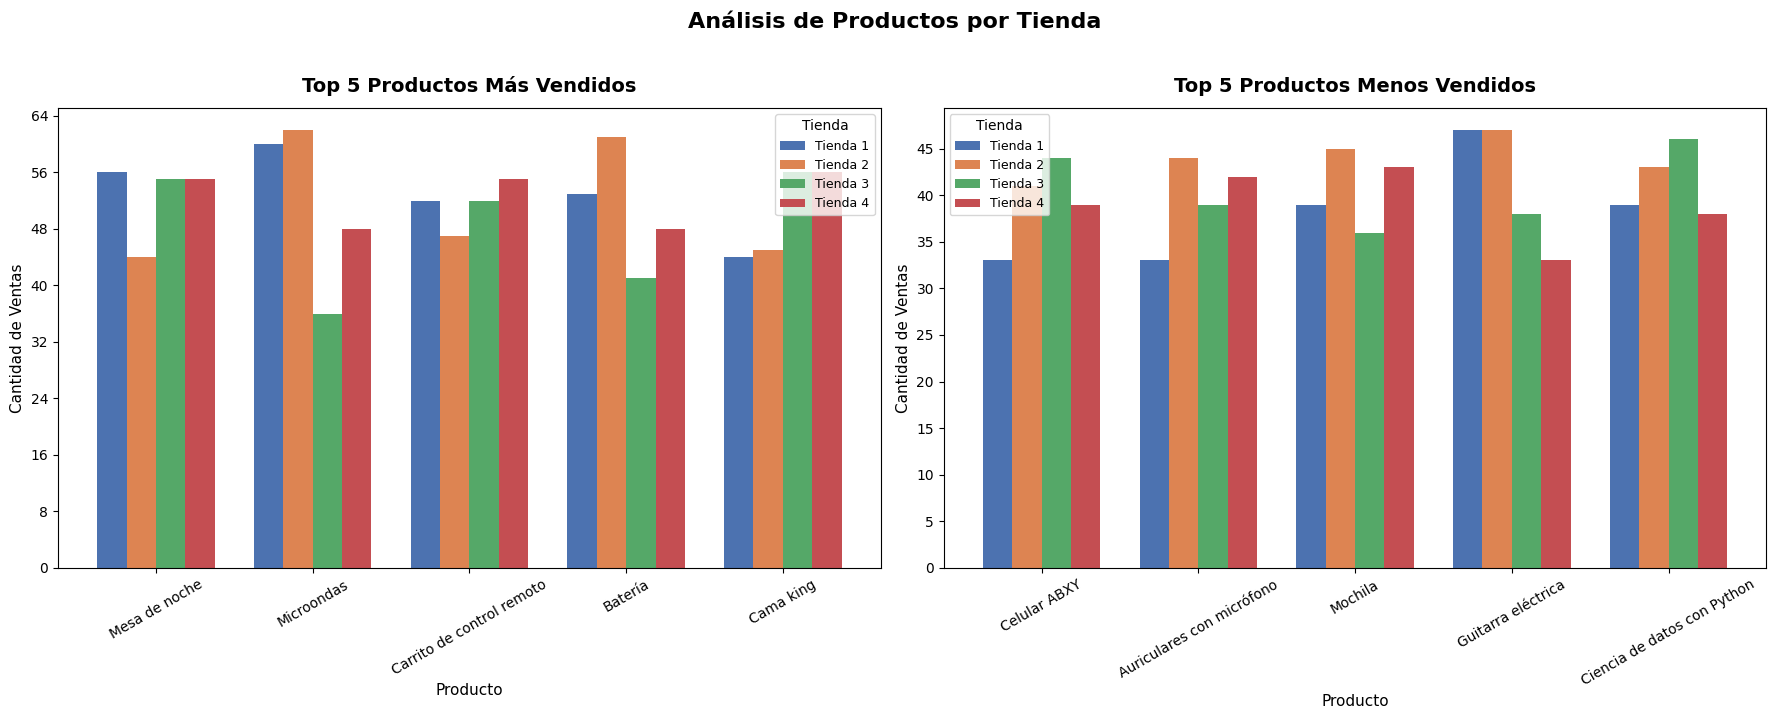

In [92]:
top5 = comparacion_productos.mean(axis=1).nlargest(5).index
bottom5 = comparacion_productos.mean(axis=1).nsmallest(5).index

colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, (grafica_mas_vendidos, grafica_menos_vendidos) = plt.subplots(
    1, 2, figsize=(18, 7)
)

comparacion_productos.loc[top5].plot(
    kind='bar', ax=grafica_mas_vendidos, color=colores, width=0.75
)
grafica_mas_vendidos.set_title('Top 5 Productos Más Vendidos', fontsize=14, fontweight='bold', pad=12)
grafica_mas_vendidos.set_xlabel('Producto', fontsize=11)
grafica_mas_vendidos.set_ylabel('Cantidad de Ventas', fontsize=11)
grafica_mas_vendidos.tick_params(axis='x', rotation=30)
grafica_mas_vendidos.legend(title='Tienda', fontsize=9)
grafica_mas_vendidos.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

comparacion_productos.loc[bottom5].plot(
    kind='bar', ax=grafica_menos_vendidos, color=colores, width=0.75
)
grafica_menos_vendidos.set_title('Top 5 Productos Menos Vendidos', fontsize=14, fontweight='bold', pad=12)
grafica_menos_vendidos.set_xlabel('Producto', fontsize=11)
grafica_menos_vendidos.set_ylabel('Cantidad de Ventas', fontsize=11)
grafica_menos_vendidos.tick_params(axis='x', rotation=30)
grafica_menos_vendidos.legend(title='Tienda', fontsize=9)
grafica_menos_vendidos.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

fig.suptitle('Análisis de Productos por Tienda', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [93]:
ventas_categorias1 = tienda['Categoría del Producto'].value_counts()
ventas_categorias2 = tienda2['Categoría del Producto'].value_counts()
ventas_categorias3 = tienda3['Categoría del Producto'].value_counts()
ventas_categorias4 = tienda4['Categoría del Producto'].value_counts()

comparacion_categorias = pd.concat(
    [ventas_categorias1, ventas_categorias2, ventas_categorias3, ventas_categorias4],
    axis=1
)

comparacion_categorias.columns = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
comparacion_categorias = comparacion_categorias.fillna(0)

comparacion_categorias

,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Categoría del Producto,,,,
Muebles,465,442,499,480
Electrónicos,448,422,451,451
Juguetes,324,313,315,338
Electrodomésticos,312,305,278,254
Deportes y diversión,284,275,277,277
Instrumentos musicales,182,224,177,170
Libros,173,197,185,187
Artículos para el hogar,171,181,177,201


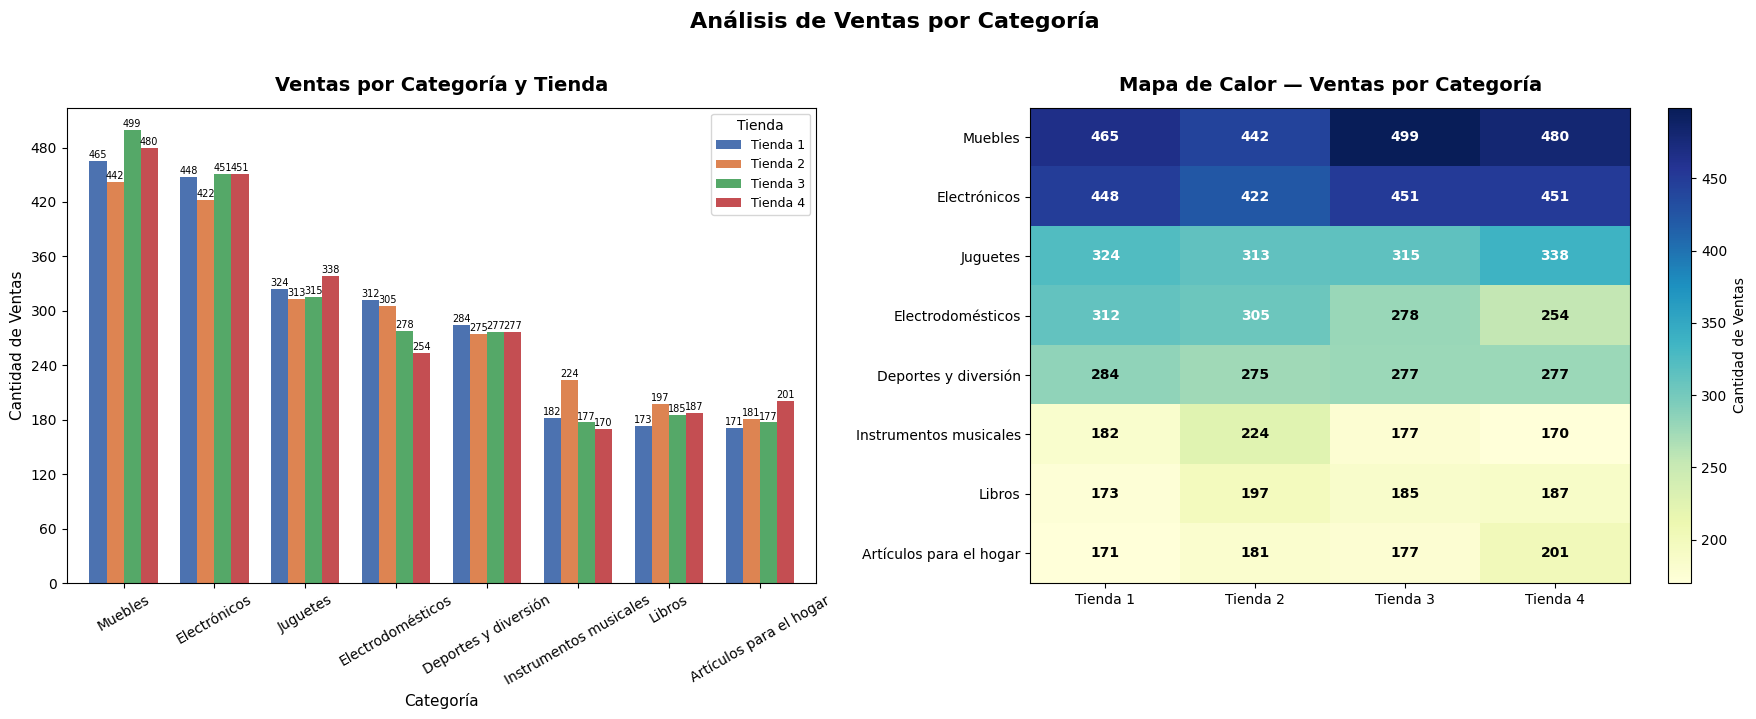

In [94]:
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, (grafica_categorias_barras, grafica_categorias_calor) = plt.subplots(
    1, 2, figsize=(18, 7)
)

comparacion_categorias.plot(
    kind='bar', ax=grafica_categorias_barras, color=colores, width=0.75
)
grafica_categorias_barras.set_title('Ventas por Categoría y Tienda', fontsize=14, fontweight='bold', pad=12)
grafica_categorias_barras.set_xlabel('Categoría', fontsize=11)
grafica_categorias_barras.set_ylabel('Cantidad de Ventas', fontsize=11)
grafica_categorias_barras.tick_params(axis='x', rotation=30)
grafica_categorias_barras.legend(title='Tienda', fontsize=9)
grafica_categorias_barras.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

for barra in grafica_categorias_barras.patches:
    valor = int(barra.get_height())
    if valor > 0:
        grafica_categorias_barras.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 1,
            str(valor),
            ha='center', va='bottom', fontsize=7
        )

import numpy as np

data = comparacion_categorias.values
categorias = comparacion_categorias.index.tolist()
tiendas = comparacion_categorias.columns.tolist()

mapa = grafica_categorias_calor.imshow(data, aspect='auto', cmap='YlGnBu')
fig.colorbar(mapa, ax=grafica_categorias_calor, label='Cantidad de Ventas')

grafica_categorias_calor.set_title('Mapa de Calor — Ventas por Categoría', fontsize=14, fontweight='bold', pad=12)
grafica_categorias_calor.set_xticks(range(len(tiendas)))
grafica_categorias_calor.set_xticklabels(tiendas, fontsize=10)
grafica_categorias_calor.set_yticks(range(len(categorias)))
grafica_categorias_calor.set_yticklabels(categorias, fontsize=10)

for i in range(len(categorias)):
    for j in range(len(tiendas)):
        grafica_categorias_calor.text(
            j, i, int(data[i, j]),
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='black' if data[i, j] < data.max() * 0.6 else 'white'
        )

fig.suptitle('Análisis de Ventas por Categoría', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [95]:
promedio_calificación1 = tienda['Calificación'].mean()
promedio_calificación2 = tienda2['Calificación'].mean()
promedio_calificación3 = tienda3['Calificación'].mean()
promedio_calificación4 = tienda4['Calificación'].mean()

comparacion_calificacion = pd.Series(
    [
        promedio_calificación1,
        promedio_calificación2,
        promedio_calificación3,
        promedio_calificación4
    ],
    index=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
)

comparacion_calificacion

,0
Tienda 1,3.976685
Tienda 2,4.037304
Tienda 3,4.048326
Tienda 4,3.995759


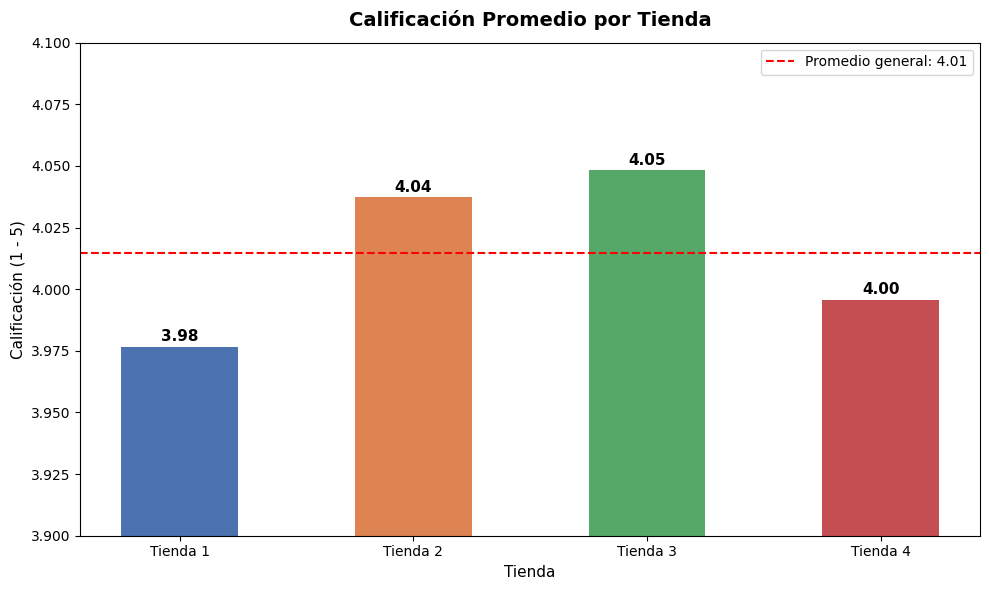

In [98]:
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
tiendas = comparacion_calificacion.index.tolist()
valores = comparacion_calificacion.values
promedio_general = np.mean(valores)

fig, grafica_calificacion = plt.subplots(figsize=(10, 6))

barras = grafica_calificacion.bar(tiendas, valores, color=colores, width=0.5)

grafica_calificacion.axhline(
    promedio_general, color='red', linestyle='--', linewidth=1.5,
    label=f'Promedio general: {promedio_general:.2f}'
)

for barra, valor in zip(barras, valores):
    grafica_calificacion.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.001,
        f'{valor:.2f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

grafica_calificacion.set_title('Calificación Promedio por Tienda', fontsize=14, fontweight='bold', pad=12)
grafica_calificacion.set_xlabel('Tienda', fontsize=11)
grafica_calificacion.set_ylabel('Calificación (1 - 5)', fontsize=11)
grafica_calificacion.set_ylim(3.9, 4.1)
grafica_calificacion.legend(fontsize=10)

plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

In [99]:
mp_tienda1 = pd.concat([ventas_productos1.head(1), ventas_productos1.tail(1)])
mp_tienda2 = pd.concat([ventas_productos2.head(1), ventas_productos2.tail(1)])
mp_tienda3 = pd.concat([ventas_productos3.head(1), ventas_productos3.tail(1)])
mp_tienda4 = pd.concat([ventas_productos4.head(1), ventas_productos4.tail(1)])

comparacion_mp = pd.concat(
    [mp_tienda1, mp_tienda2, mp_tienda3, mp_tienda4],
    axis=1
)

comparacion_mp.columns = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
comparacion_mp = comparacion_mp.fillna(0)

comparacion_mp

,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Producto,,,,
Microondas,60.0,0.0,0.0,0.0
Celular ABXY,33.0,0.0,0.0,0.0
Iniciando en programación,0.0,65.0,0.0,0.0
Juego de mesa,0.0,32.0,0.0,0.0
Kit de bancas,0.0,0.0,57.0,0.0
Bloques de construcción,0.0,0.0,35.0,0.0
Cama box,0.0,0.0,0.0,62.0
Guitarra eléctrica,0.0,0.0,0.0,33.0


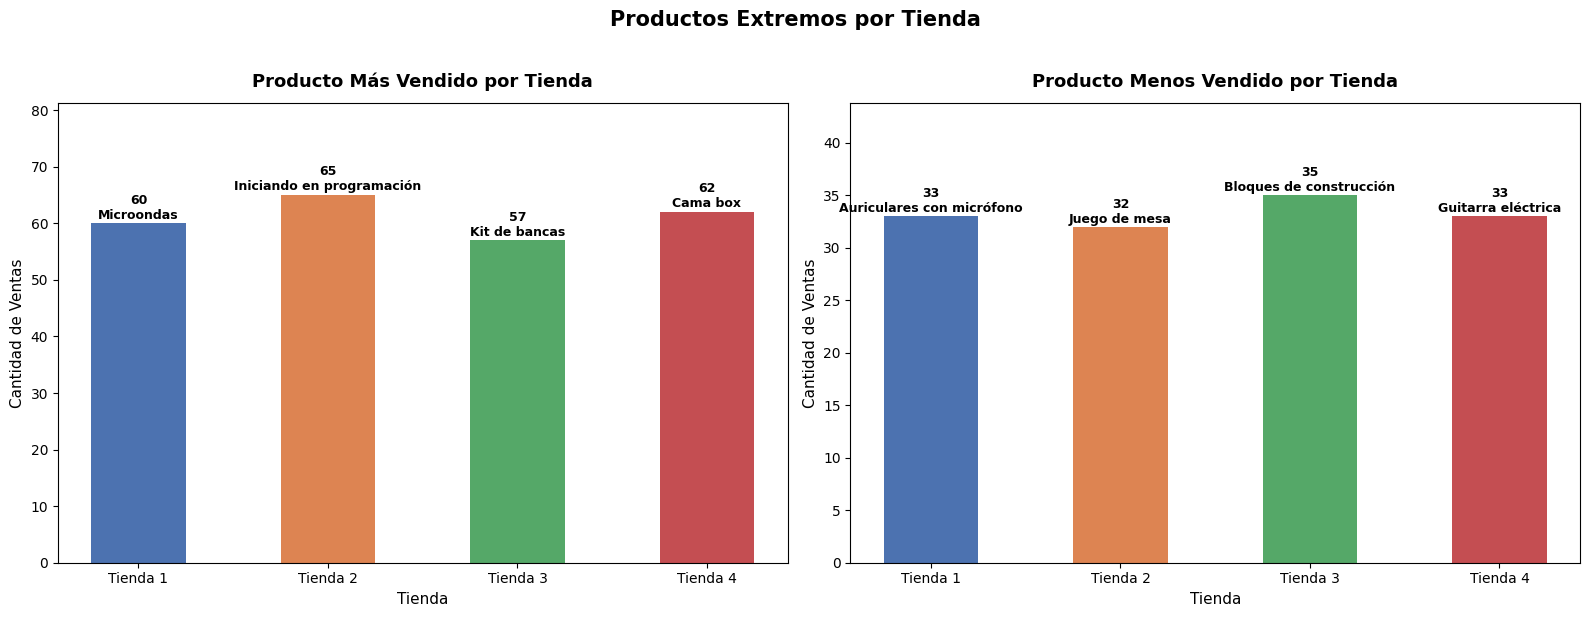

In [100]:
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

mas_vendidos = [ventas_productos1.idxmax(), ventas_productos2.idxmax(),
                ventas_productos3.idxmax(), ventas_productos4.idxmax()]
menos_vendidos = [ventas_productos1.idxmin(), ventas_productos2.idxmin(),
                  ventas_productos3.idxmin(), ventas_productos4.idxmin()]

valores_mas = [ventas_productos1.max(), ventas_productos2.max(),
               ventas_productos3.max(), ventas_productos4.max()]
valores_menos = [ventas_productos1.min(), ventas_productos2.min(),
                 ventas_productos3.min(), ventas_productos4.min()]

fig, (grafica_mas_vendidos, grafica_menos_vendidos) = plt.subplots(1, 2, figsize=(16, 6))

barras_mas = grafica_mas_vendidos.bar(tiendas, valores_mas, color=colores, width=0.5)

for barra, valor, producto in zip(barras_mas, valores_mas, mas_vendidos):
    grafica_mas_vendidos.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.3,
        f'{valor}\n{producto}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

grafica_mas_vendidos.set_title('Producto Más Vendido por Tienda', fontsize=13, fontweight='bold', pad=12)
grafica_mas_vendidos.set_xlabel('Tienda', fontsize=11)
grafica_mas_vendidos.set_ylabel('Cantidad de Ventas', fontsize=11)
grafica_mas_vendidos.set_ylim(0, max(valores_mas) * 1.25)

barras_menos = grafica_menos_vendidos.bar(tiendas, valores_menos, color=colores, width=0.5)

for barra, valor, producto in zip(barras_menos, valores_menos, menos_vendidos):
    grafica_menos_vendidos.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.1,
        f'{valor}\n{producto}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

grafica_menos_vendidos.set_title('Producto Menos Vendido por Tienda', fontsize=13, fontweight='bold', pad=12)
grafica_menos_vendidos.set_xlabel('Tienda', fontsize=11)
grafica_menos_vendidos.set_ylabel('Cantidad de Ventas', fontsize=11)
grafica_menos_vendidos.set_ylim(0, max(valores_menos) * 1.25)

fig.suptitle('Productos Extremos por Tienda', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [101]:
promedio_envio1 = tienda['Costo de envío'].mean()
promedio_envio2 = tienda2['Costo de envío'].mean()
promedio_envio3 = tienda3['Costo de envío'].mean()
promedio_envio4 = tienda4['Costo de envío'].mean()

comparacion_envio = pd.Series(
    [promedio_envio1, promedio_envio2, promedio_envio3, promedio_envio4],
    index=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
)

comparacion_envio

,0
Tienda 1,26018.609580
Tienda 2,25216.235693
Tienda 3,24805.680373
Tienda 4,23459.457167


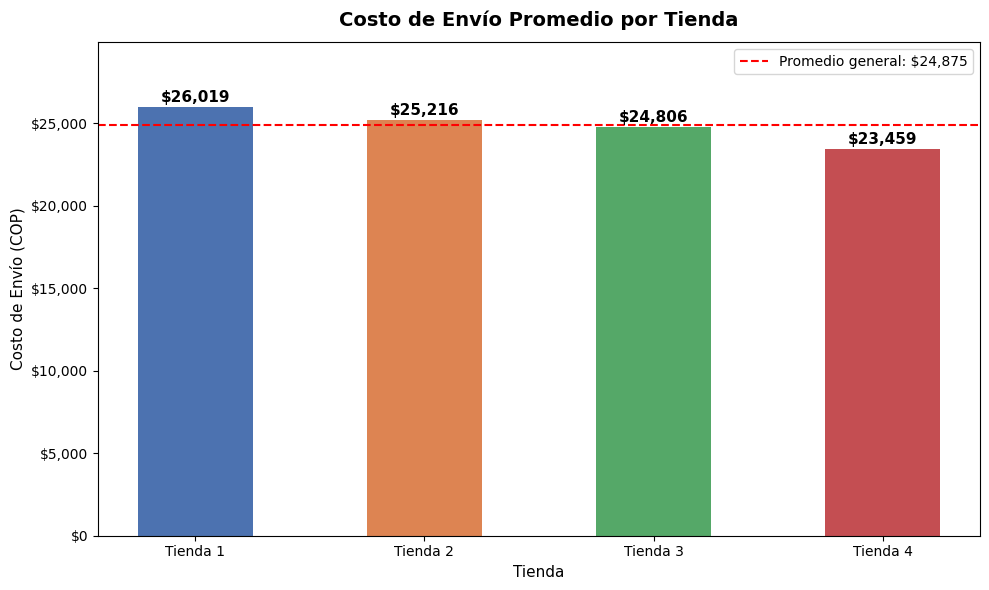

In [103]:
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
tiendas = comparacion_envio.index.tolist()
valores = comparacion_envio.values
promedio_general = np.mean(valores)

fig, grafica_envio = plt.subplots(figsize=(10, 6))

barras = grafica_envio.bar(tiendas, valores, color=colores, width=0.5)

grafica_envio.axhline(
    promedio_general, color='red', linestyle='--', linewidth=1.5,
    label=f'Promedio general: ${promedio_general:,.0f}'
)

for barra, valor in zip(barras, valores):
    grafica_envio.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 100,
        f'${valor:,.0f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

grafica_envio.set_title('Costo de Envío Promedio por Tienda', fontsize=14, fontweight='bold', pad=12)
grafica_envio.set_xlabel('Tienda', fontsize=11)
grafica_envio.set_ylabel('Costo de Envío (COP)', fontsize=11)
grafica_envio.set_ylim(0, max(valores) * 1.15)
grafica_envio.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
grafica_envio.legend(fontsize=10)

plt.tight_layout()
plt.show()